# 03 — Modeling
## Telco Customer Churn

**Goal:** Train an XGBoost model using all features built in 02_feature_engineering
to predict the probability of churn for each customer.

**Pipeline:**

| Step | What happens |
|------|-------------|
| 1 | Load and prepare data |
| 2 | Run full feature engineering pipeline |
| 3 | Combine train + original for more data |
| 4 | StratifiedKFold cross-validation (10 folds) |
| 5 | Target Encoding per fold (no leakage) |
| 6 | Train XGBoost per fold with early stopping |
| 7 | Calculate OOF AUC (honest evaluation metric) |
| 8 | Generate final predictions on test set |
| 9 | Save submission.csv |

**Key metric: OOF AUC (Out-of-Fold AUC)**
Each customer is predicted exactly once — when their fold
was held out for validation. The model never saw that customer
during training for that prediction.

| AUC | Interpretation |
|-----|----------------|
| 1.0 | Perfect model |
| 0.9+ | Excellent |
| 0.8+ | Good |
| 0.7+ | Acceptable |
| 0.5 | Random guessing |

In [1]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
os.makedirs('../outputs', exist_ok=True)
print("Libraries loaded.")

# =============================================================================
# Configuration
# =============================================================================
class CFG:
    TARGET      = 'Churn'
    N_FOLDS     = 10
    INNER_FOLDS = 5
    RANDOM_SEED = 42
    TRAIN_PATH    = "../data/train.csv"
    TEST_PATH     = "../data/test.csv"
    ORIGINAL_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

XGB_PARAMS = {
    'n_estimators'         : 3000,
    'learning_rate'        : 0.02,
    'max_depth'            : 6,
    'subsample'            : 0.85,
    'colsample_bytree'     : 0.5,
    'min_child_weight'     : 4,
    'reg_alpha'            : 2.0,
    'reg_lambda'           : 1.0,
    'gamma'                : 0.5,
    'random_state'         : CFG.RANDOM_SEED,
    'early_stopping_rounds': 100,
    'objective'            : 'binary:logistic',
    'eval_metric'          : 'auc',
    'enable_categorical'   : True,
    'device'               : 'cpu',
    'verbosity'            : 0,
}

NUM_COLS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CAT_COLS = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = NUM_COLS
CATS = CAT_COLS

print("✓ Configuration loaded.")

# =============================================================================
# 1. Load Data
# =============================================================================
print("\nLoading datasets...")
train = pd.read_csv(CFG.TRAIN_PATH)
test  = pd.read_csv(CFG.TEST_PATH)
orig  = pd.read_csv(CFG.ORIGINAL_PATH)

for df in [train, test, orig]:
    df.rename(columns={'gender': 'Gender', 'tenure': 'Tenure'}, inplace=True)

train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET]  = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

train_ids = train['id'].copy()
test_ids  = test['id'].copy()

print(f"✓ Train : {train.shape}")
print(f"✓ Test  : {test.shape}")
print(f"✓ Orig  : {orig.shape}")

Libraries loaded.
✓ Configuration loaded.

Loading datasets...
✓ Train : (5634, 22)
✓ Test  : (1409, 21)
✓ Orig  : (7043, 20)


## Step 3 — Feature Engineering (Full Pipeline)

**Goal:** Transform raw variables into 125+ informative features
for the model. This replicates the full pipeline from
02_feature_engineering.ipynb in a single condensed cell.

| Step | Type | Features added |
|------|------|----------------|
| 1 | Frequency Encoding | 3 |
| 2 | Arithmetic Interactions | 3 |
| 3 | Service Counts | 5 |
| 4 | Target Encoding (ORIG_proba) | 19 |
| 5 | Distribution Features | 6 |
| 6 | Quantile Distance | 9 |
| 7 | Digit Features | 32 |
| 8 | N-gram Features | 19 |
| **Total new** | | **96 features** |

**Note:** ORIG_proba features are calculated here for reference
only — they will be **excluded from the final feature set**
and recalculated per fold inside cross-validation to avoid
data leakage.
```




In [2]:
# =============================================================================
# 3. Feature Engineering (full pipeline)
# =============================================================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

CATS = CAT_COLS
NUMS = NUM_COLS

NEW_NUMS          = []
NUM_AS_CAT        = []
RATIO_COLS        = []
SERVICE_COLS      = []
ORIG_PROBA_COLS   = []
DIST_FEATURES     = []
QUANTILE_FEATURES = []
DIGIT_FEATURES    = []
BIGRAM_COLS       = []
TRIGRAM_COLS      = []

# --- Step 1: Frequency Encoding ---
print("[1/8] Frequency Encoding...")
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')

# --- Step 2: Arithmetic Interactions ---
print("[2/8] Arithmetic Interactions...")
for df in [train, test, orig]:
    df['TotalCharges']   = pd.to_numeric(df['TotalCharges'],   errors='coerce').fillna(0)
    df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce').fillna(0)
    df['Tenure']         = pd.to_numeric(df['Tenure'],         errors='coerce').fillna(0)
    df['charges_deviation']      = (df['TotalCharges'] - df['Tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges']    = (df['TotalCharges'] / (df['Tenure'] + 1)).astype('float32')
    df['tenure_contract_ratio']  = (df['Tenure'] / (df['MonthlyCharges'] + 1)).astype('float32')

NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges', 'tenure_contract_ratio']

# --- Step 3: Service Counts ---
print("[3/8] Service Counts...")
SERVICE_BINARY_COLS = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for df in [train, test, orig]:
    for col in SERVICE_BINARY_COLS:
        df[f'has_{col}'] = (df[col] == 'Yes').astype('float32')
    df['n_services']    = df[[f'has_{col}' for col in SERVICE_BINARY_COLS]].sum(axis=1).astype('float32')
    df['has_internet']  = (df['InternetService'] != 'No').astype('float32')
    df['has_streaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype('float32')
    df['has_security']  = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype('float32')
    df['service_ratio'] = (df['n_services'] / len(SERVICE_BINARY_COLS)).astype('float32')
    # Nuevas features que dependen de n_services
    df['charge_per_service'] = (df['MonthlyCharges'] / (df['n_services'] + 1)).astype('float32')
    df['total_per_service']  = (df['TotalCharges']   / (df['n_services'] + 1)).astype('float32')

SERVICE_COLS = [
    'n_services', 'has_internet', 'has_streaming', 'has_security',
    'service_ratio', 'charge_per_service', 'total_per_service'
]
NEW_NUMS += SERVICE_COLS
# --- Step 4: Target Encoding (ORIG_proba) ---
print("[4/8] Target Encoding...")
ORIG_PROBA_COLS = []
for col in CAT_COLS + NUM_COLS:
    tmp = train.groupby(col)[CFG.TARGET].mean()
    col_name = f'ORIG_proba_{col}'
    for df in [train, test, orig]:
        df[col_name] = df[col].map(tmp).fillna(0.5).astype('float32')
    ORIG_PROBA_COLS.append(col_name)
    NEW_NUMS.append(col_name)

# --- Step 5: Distribution Features ---
print("[5/8] Distribution Features...")
churner_tc    = train[train[CFG.TARGET] == 1]['TotalCharges'].values
nonchurner_tc = train[train[CFG.TARGET] == 0]['TotalCharges'].values
ch_sorted     = np.sort(churner_tc)
nc_sorted     = np.sort(nonchurner_tc)

for df in [train, test, orig]:
    df['pctrank_churner_TC']    = df['TotalCharges'].apply(
        lambda x: np.searchsorted(ch_sorted, x) / len(ch_sorted)).astype('float32')
    df['pctrank_nonchurner_TC'] = df['TotalCharges'].apply(
        lambda x: np.searchsorted(nc_sorted, x) / len(nc_sorted)).astype('float32')
    df['pctrank_churn_gap_TC']  = (df['pctrank_churner_TC'] - df['pctrank_nonchurner_TC']).astype('float32')
    df['zscore_churn_gap_TC']   = (
        (df['TotalCharges'] - churner_tc.mean()) / (churner_tc.std() + 1e-8)
      - (df['TotalCharges'] - nonchurner_tc.mean()) / (nonchurner_tc.std() + 1e-8)
    ).astype('float32')
    df['zscore_nonchurner_TC']  = (
        (df['TotalCharges'] - nonchurner_tc.mean()) / (nonchurner_tc.std() + 1e-8)
    ).astype('float32')
    is_means = train.groupby('InternetService')['MonthlyCharges'].mean()
    df['resid_IS_MC']        = (df['MonthlyCharges'] - df['InternetService'].map(is_means)).astype('float32')
    df['cond_pctrank_IS_TC'] = df.groupby('InternetService')['TotalCharges'].rank(pct=True).astype('float32')
    df['cond_pctrank_C_TC']  = df.groupby('Contract')['TotalCharges'].rank(pct=True).astype('float32')

DIST_FEATURES = [
    'pctrank_churn_gap_TC', 'zscore_churn_gap_TC', 'zscore_nonchurner_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES

# --- Step 6: Quantile Distance ---
print("[6/8] Quantile Distance...")
QUANTILE_FEATURES = []
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(churner_tc, q_val)
    nc_q = np.quantile(nonchurner_tc, q_val)
    for df in [train, test, orig]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_{q_label}']  = (df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']).astype('float32')
    QUANTILE_FEATURES += [f'dist_To_ch_{q_label}', f'dist_To_nc_{q_label}', f'qdist_gap_{q_label}']
NEW_NUMS += QUANTILE_FEATURES

# --- Step 7: Digit Features ---
print("[7/8] Digit Features...")
for df_iter in [train, test, orig]:
    t_str = df_iter['Tenure'].astype(str)
    df_iter['tenure_first_digit']      = t_str.str[0].astype(int)
    df_iter['tenure_last_digit']       = t_str.str[-1].astype(int)
    df_iter['tenure_mod10']            = df_iter['Tenure'] % 10
    df_iter['tenure_mod12']            = df_iter['Tenure'] % 12
    df_iter['tenure_num_digits']       = t_str.str.len()
    df_iter['tenure_is_multiple_10']   = (df_iter['Tenure'] % 10 == 0).astype('float32')
    df_iter['tenure_rounded_10']       = np.round(df_iter['Tenure'] / 10) * 10
    df_iter['tenure_dev_from_round10'] = np.abs(df_iter['Tenure'] - df_iter['tenure_rounded_10'])
    df_iter['tenure_years']            = df_iter['Tenure'] // 12
    df_iter['tenure_months_in_year']   = df_iter['Tenure'] % 12
    mc_str = df_iter['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['mc_first_digit']      = mc_str.str[0].astype(int)
    df_iter['mc_last_digit']       = mc_str.str[-1].astype(int)
    df_iter['mc_mod10']            = np.floor(df_iter['MonthlyCharges']) % 10
    df_iter['mc_mod100']           = np.floor(df_iter['MonthlyCharges']) % 100
    df_iter['mc_num_digits']       = np.floor(df_iter['MonthlyCharges']).astype(int).astype(str).str.len()
    df_iter['mc_is_multiple_10']   = (np.floor(df_iter['MonthlyCharges']) % 10 == 0).astype('float32')
    df_iter['mc_is_multiple_50']   = (np.floor(df_iter['MonthlyCharges']) % 50 == 0).astype('float32')
    df_iter['mc_rounded_10']       = np.round(df_iter['MonthlyCharges'] / 10) * 10
    df_iter['mc_fractional']       = df_iter['MonthlyCharges'] - np.floor(df_iter['MonthlyCharges'])
    df_iter['mc_dev_from_round10'] = np.abs(df_iter['MonthlyCharges'] - df_iter['mc_rounded_10'])
    df_iter['mc_per_digit']        = df_iter['MonthlyCharges'] / (df_iter['mc_num_digits'] + 0.001)
    tc_str = df_iter['TotalCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['tc_first_digit']       = tc_str.str[0].astype(int)
    df_iter['tc_last_digit']        = tc_str.str[-1].astype(int)
    df_iter['tc_mod10']             = np.floor(df_iter['TotalCharges']) % 10
    df_iter['tc_mod100']            = np.floor(df_iter['TotalCharges']) % 100
    df_iter['tc_num_digits']        = np.floor(df_iter['TotalCharges']).astype(int).astype(str).str.len()
    df_iter['tc_is_multiple_10']    = (np.floor(df_iter['TotalCharges']) % 10 == 0).astype('float32')
    df_iter['tc_is_multiple_100']   = (np.floor(df_iter['TotalCharges']) % 100 == 0).astype('float32')
    df_iter['tc_rounded_100']       = np.round(df_iter['TotalCharges'] / 100) * 100
    df_iter['tc_fractional']        = df_iter['TotalCharges'] - np.floor(df_iter['TotalCharges'])
    df_iter['tc_dev_from_round100'] = np.abs(df_iter['TotalCharges'] - df_iter['tc_rounded_100'])
    df_iter['tc_per_digit']         = df_iter['TotalCharges'] / (df_iter['tc_num_digits'] + 0.001)

DIGIT_FEATURES = [
    'tenure_first_digit', 'tenure_last_digit', 'tenure_mod10', 'tenure_mod12',
    'tenure_num_digits', 'tenure_is_multiple_10', 'tenure_rounded_10',
    'tenure_dev_from_round10', 'tenure_years', 'tenure_months_in_year',
    'mc_first_digit', 'mc_last_digit', 'mc_mod10', 'mc_mod100',
    'mc_num_digits', 'mc_is_multiple_10', 'mc_is_multiple_50',
    'mc_rounded_10', 'mc_fractional', 'mc_dev_from_round10', 'mc_per_digit',
    'tc_first_digit', 'tc_last_digit', 'tc_mod10', 'tc_mod100',
    'tc_num_digits', 'tc_is_multiple_10', 'tc_is_multiple_100',
    'tc_rounded_100', 'tc_fractional', 'tc_dev_from_round100', 'tc_per_digit'
]
NEW_NUMS += DIGIT_FEATURES

# --- Step 8: N-gram Features ---
print("[8/8] N-gram Features...")
BIGRAM_COLS  = []
TRIGRAM_COLS = []
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f'BG_{c1}_{c2}'
    for df in [train, test, orig]:
        df[col_name] = df[c1].astype(str) + '_' + df[c2].astype(str)
    BIGRAM_COLS.append(col_name)
TOP4 = TOP_CATS_FOR_NGRAM[:4]
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f'TG_{c1}_{c2}_{c3}'
    for df in [train, test, orig]:
        df[col_name] = df[c1].astype(str) + '_' + df[c2].astype(str) + '_' + df[c3].astype(str)
    TRIGRAM_COLS.append(col_name)

print(f'\n✓ Feature Engineering complete')
print(f'✓ Train shape : {train.shape}')
print(f'✓ Test shape  : {test.shape}')
print(f'✓ NEW_NUMS    : {len(NEW_NUMS)}')
print(f'✓ BIGRAM_COLS : {len(BIGRAM_COLS)}')
print(f'✓ TRIGRAM_COLS: {len(TRIGRAM_COLS)}')
print(f'✓ Total features: {len(train.columns)}')




FEATURE ENGINEERING
[1/8] Frequency Encoding...
[2/8] Arithmetic Interactions...
[3/8] Service Counts...
[4/8] Target Encoding...
[5/8] Distribution Features...
[6/8] Quantile Distance...
[7/8] Digit Features...
[8/8] N-gram Features...

✓ Feature Engineering complete
✓ Train shape : (5634, 131)
✓ Test shape  : (1409, 130)
✓ NEW_NUMS    : 80
✓ BIGRAM_COLS : 15
✓ TRIGRAM_COLS: 4
✓ Total features: 131


## Step 4 — Prepare Final Features

**Goal:** Select which columns enter the model and define
the feature matrix (X) and target vector (y).

**Feature groups entering the model:**

| Group | Examples | Count |
|-------|---------|-------|
| Original numericals | Tenure, MonthlyCharges, TotalCharges | 3 |
| Original categoricals | Contract, InternetService, PaymentMethod... | 16 |
| Frequency Encoding | FREQ_Tenure, FREQ_MonthlyCharges... | 3 |
| Arithmetic Interactions | avg_monthly_charges, charges_deviation... | 3 |
| Service Counts | n_services, has_internet, has_security... | 5 |
| Target Encoding | ORIG_proba_Contract, ORIG_proba_Tenure... | 19 |
| Distribution Features | pctrank_churn_gap_TC, resid_IS_MC... | 6 |
| Quantile Distance | qdist_gap_q50, dist_To_ch_q25... | 9 |
| Digit Features | tenure_mod12, mc_first_digit... | 32 |
| N-gram Features | BG_Contract_InternetService... | 19 |
| **Total** | | **~115 features** |

**Columns excluded:**
- `id` — identifier, no predictive value
- `customerID` — identifier
- `Churn` — this is the target, not a feature

**Categorical handling:**
XGBoost with `enable_categorical=True` handles categorical
columns natively — no need for one-hot encoding.
Categorical columns are cast to `category` dtype.

In [3]:
# =============================================================================
# 4. Prepare Final Features
# =============================================================================
print("\n" + "="*60)
print("PREPARING FEATURES")
print("="*60)

# Columns to exclude
EXCLUDE_COLS = ['id', 'customerID', CFG.TARGET]

# Feature columns — everything except excluded
FEATURE_COLS = [col for col in train.columns if col not in EXCLUDE_COLS]

# Eliminar ORIG_proba — el TargetEncoder del fold las recalcula sin leakage
FEATURE_COLS = [col for col in FEATURE_COLS if not col.startswith('ORIG_proba_')]

# Separate numerical and categorical features
CAT_FEATURES = CATS + BIGRAM_COLS + TRIGRAM_COLS
NUM_FEATURES = [col for col in FEATURE_COLS if col not in CAT_FEATURES]

# Cast categoricals to category dtype for XGBoost
for df in [train, test, orig]:
    for col in CAT_FEATURES:
        if col in df.columns:
            df[col] = df[col].astype('category')

# Define X and y
X      = train[FEATURE_COLS].copy()
y      = train[CFG.TARGET].copy()
X_test = test[FEATURE_COLS].copy()

print(f"✓ Total features      : {len(FEATURE_COLS)}")
print(f"✓ Numerical features  : {len(NUM_FEATURES)}")
print(f"✓ Categorical features: {len(CAT_FEATURES)}")
print(f"✓ ORIG_proba excluded : {sum(1 for c in train.columns if c.startswith('ORIG_proba_'))} cols removed")
print(f"✓ X shape    : {X.shape}")
print(f"✓ y shape    : {y.shape}")
print(f"✓ X_test shape: {X_test.shape}")
print(f"\nChurn rate in y: {y.mean()*100:.1f}%")


PREPARING FEATURES
✓ Total features      : 109
✓ Numerical features  : 74
✓ Categorical features: 35
✓ ORIG_proba excluded : 19 cols removed
✓ X shape    : (5634, 109)
✓ y shape    : (5634,)
✓ X_test shape: (1409, 109)

Churn rate in y: 26.5%


## Step 5 — Combine Train + Original Data

**Goal:** Increase the training data by combining the competition
train set with the original IBM Telco dataset.

**Why it helps:**
- Train set: 5,634 customers (synthetic, from Kaggle competition)
- Original:  7,043 customers (real IBM Telco data)
- Combined: 12,677 customers → 2.25x more training data

**Important considerations:**
- The original dataset does NOT have an `id` column → excluded from combined
- The test set stays separate — never mixed with training data
- The combined dataset is only used for training, not for OOF evaluation
- OOF AUC is calculated only on the original train set (5,634 customers)
  so the metric remains comparable and honest

**Result:** More data → model sees more patterns → better generalization

In [4]:
# =============================================================================
# 5. Combine Train + Original Data
# =============================================================================
print("\n" + "="*60)
print("COMBINING TRAIN + ORIGINAL")
print("="*60)

# Original no tiene columna 'id' — usar solo feature cols compartidas
ORIG_FEATURE_COLS = [col for col in FEATURE_COLS if col in orig.columns]

X_orig = orig[ORIG_FEATURE_COLS].copy()
y_orig = orig[CFG.TARGET].copy()

# Alinear columnas — orig puede tener menos features
# Las columnas faltantes se rellenan con NaN
X_combined = pd.concat([X, X_orig], axis=0, ignore_index=True)
y_combined = pd.concat([y, y_orig], axis=0, ignore_index=True)

# Re-castear categoricals después del concat
for col in CAT_FEATURES:
    if col in X_combined.columns:
        X_combined[col] = X_combined[col].astype('category')

print(f"✓ X shape          : {X.shape}")
print(f"✓ X_orig shape     : {X_orig.shape}")
print(f"✓ X_combined shape : {X_combined.shape}")
print(f"✓ y_combined shape : {y_combined.shape}")
print(f"\nChurn rate — train   : {y.mean()*100:.1f}%")
print(f"Churn rate — original: {y_orig.mean()*100:.1f}%")
print(f"Churn rate — combined: {y_combined.mean()*100:.1f}%")


COMBINING TRAIN + ORIGINAL
✓ X shape          : (5634, 109)
✓ X_orig shape     : (7043, 109)
✓ X_combined shape : (12677, 109)
✓ y_combined shape : (12677,)

Churn rate — train   : 26.5%
Churn rate — original: 26.5%
Churn rate — combined: 26.5%


## Step 6 — Cross-Validation + Training

**Goal:** Train XGBoost using StratifiedKFold cross-validation
to get an honest estimate of model performance.

**How it works:**
```
X_combined (12,677 rows)
        ↓
StratifiedKFold(n_splits=10)
        ↓
For each fold (10 iterations):
  1. Split X into fold_train / fold_eval
  2. Fit TargetEncoder on fold_train only (no leakage)
  3. Transform fold_train + fold_eval + X_test
  4. Train XGBoost with early stopping
  5. Predict on fold_eval → store OOF predictions
  6. Predict on X_test → accumulate test predictions
        ↓
OOF AUC = AUC(y_train, oof_predictions)
Final test predictions = mean of 10 fold predictions
```

**Key concepts:**
- **OOF (Out-of-Fold):** Each training customer is predicted
  exactly once when their fold was held out
- **Early stopping:** Training stops when AUC stops improving
  for 50 consecutive rounds — prevents overfitting
- **TargetEncoder per fold:** Recalculates churn rate per group
  using only fold_train data — avoids leakage

In [5]:
# =============================================================================
# 6. Cross-Validation + Training
# =============================================================================
print("\n" + "="*60)
print("CROSS-VALIDATION + TRAINING")
print("="*60)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
oof_scores = []

# Target encoding columns
TE_COLS = CAT_COLS + NUM_COLS

# Convertir categoricals a string antes de cualquier operación
for col in CAT_FEATURES:
    for df in [X, X_test, X_combined]:
        if col in df.columns:
            df[col] = df[col].astype(str).astype('category')

skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{CFG.N_FOLDS} ---")

    X_tr = X_combined.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y_combined.iloc[train_idx].copy()
    y_val = y.iloc[val_idx].copy()
    X_te  = X_test.copy()

    # Target Encoding sin leakage
    te_cols_present = [col for col in TE_COLS if col in X_tr.columns]
    if te_cols_present:
        te = TargetEncoder(
            categories='auto',
            target_type='binary',
            smooth='auto',
            cv=CFG.INNER_FOLDS,
            random_state=CFG.RANDOM_SEED
        )
        X_tr[te_cols_present]  = te.fit_transform(X_tr[te_cols_present], y_tr)
        X_val[te_cols_present] = te.transform(X_val[te_cols_present])
        X_te[te_cols_present]  = te.transform(X_te[te_cols_present])

    # Categoricals como string → category (después del TE que convierte a float)
    non_te_cats = [col for col in CAT_FEATURES if col not in te_cols_present]
    for col in non_te_cats:
        if col in X_tr.columns:
            X_tr[col]  = X_tr[col].astype(str).astype('category')
            X_val[col] = X_val[col].astype(str).astype('category')
            X_te[col]  = X_te[col].astype(str).astype('category')

    # TE cols → float (ya lo son, solo asegurar)
    for col in te_cols_present:
        if col in X_tr.columns:
            X_tr[col]  = X_tr[col].astype('float32')
            X_val[col] = X_val[col].astype('float32')
            X_te[col]  = X_te[col].astype('float32')

    # Train XGBoost
    model = XGBClassifier(**XGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred  = model.predict_proba(X_val)[:, 1]
    test_pred = model.predict_proba(X_te)[:, 1]

    oof_preds[val_idx] = val_pred
    test_preds        += test_pred / CFG.N_FOLDS

    fold_auc = roc_auc_score(y_val, val_pred)
    oof_scores.append(fold_auc)
    print(f"    AUC: {fold_auc:.5f} | Best iteration: {model.best_iteration}")

    gc.collect()

elapsed = time.time() - start_time
oof_auc = roc_auc_score(y, oof_preds)

print(f"\n{'='*60}")
print(f"CROSS-VALIDATION COMPLETE")
print(f"{'='*60}")
print(f"OOF AUC        : {oof_auc:.5f}")
print(f"Mean Fold AUC  : {np.mean(oof_scores):.5f} ± {np.std(oof_scores):.5f}")
print(f"Min Fold AUC   : {np.min(oof_scores):.5f}")
print(f"Max Fold AUC   : {np.max(oof_scores):.5f}")
print(f"Time elapsed   : {elapsed/60:.1f} min")


CROSS-VALIDATION + TRAINING

--- Fold 1/10 ---
    AUC: 0.82982 | Best iteration: 26

--- Fold 2/10 ---
    AUC: 0.85860 | Best iteration: 221

--- Fold 3/10 ---
    AUC: 0.84180 | Best iteration: 1

--- Fold 4/10 ---
    AUC: 0.83230 | Best iteration: 353

--- Fold 5/10 ---
    AUC: 0.83742 | Best iteration: 9

--- Fold 6/10 ---
    AUC: 0.84780 | Best iteration: 160

--- Fold 7/10 ---
    AUC: 0.85823 | Best iteration: 56

--- Fold 8/10 ---
    AUC: 0.85679 | Best iteration: 79

--- Fold 9/10 ---
    AUC: 0.85359 | Best iteration: 48

--- Fold 10/10 ---
    AUC: 0.86536 | Best iteration: 109

CROSS-VALIDATION COMPLETE
OOF AUC        : 0.82102
Mean Fold AUC  : 0.84817 ± 0.01163
Min Fold AUC   : 0.82982
Max Fold AUC   : 0.86536
Time elapsed   : 0.2 min


## Step 7 — Results Visualization & Submission

**Goal:** Visualize model performance and generate the
final submission file for Kaggle.

**What we show:**

| Plot | What it reveals |
|------|----------------|
| OOF Predictions Distribution | How well the model separates churners vs non-churners |
| AUC per Fold | Consistency of the model across 10 folds |
| Test Predictions Distribution | Shape of final predictions on unseen data |

**How to read the OOF Distribution:**
- Blue peak near 0 → model is confident these are NOT churners
- Orange peak near 1 → model is confident these ARE churners
- Overlap in the middle → uncertain zone where the model struggles

**Submission format:**
Kaggle expects a probability (0-1) per customer, not a binary
prediction. Higher probability = higher churn risk.

| id | Churn |
|----|-------|
| 0  | 0.234 |
| 1  | 0.891 |
| 2  | 0.043 |

**Final metric: OOF AUC**
The honest estimate of how well this model would perform
on completely new, unseen customers.


RESULTS & SUBMISSION


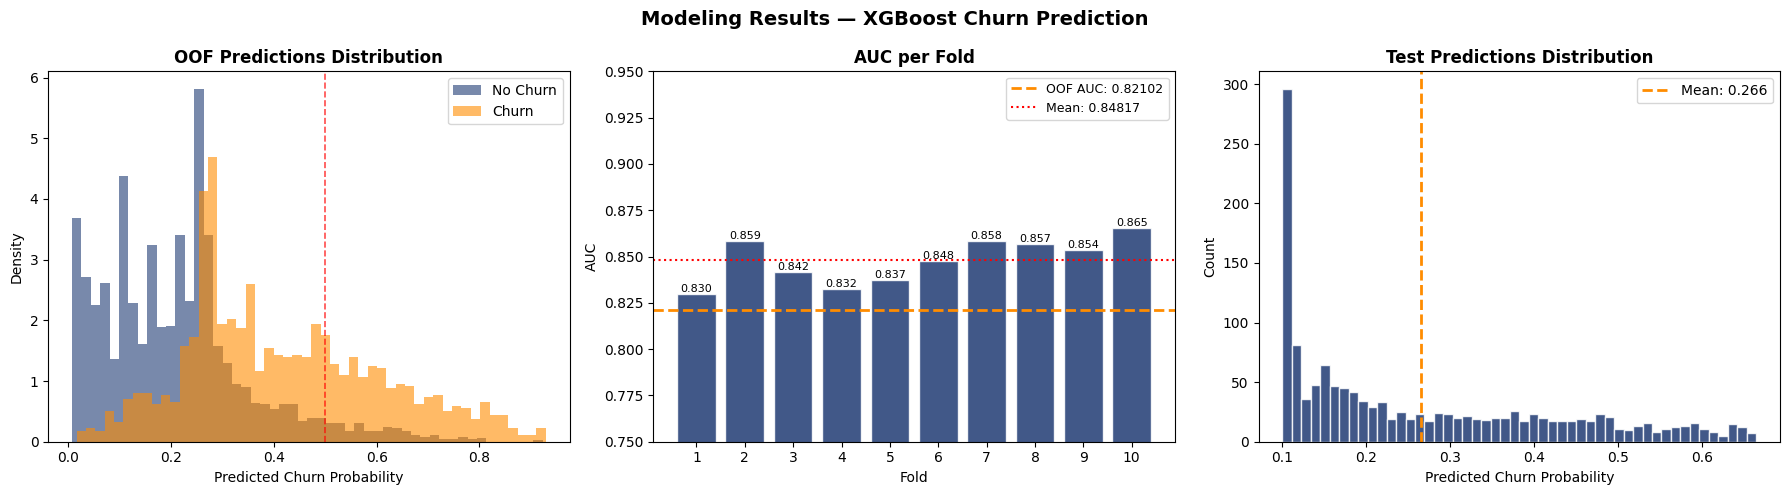


Final Results:
  OOF AUC      : 0.82102
  Mean Fold AUC: 0.84817 ± 0.01163
  Test preds   : min=0.101 | mean=0.266 | max=0.665

✓ Submission saved: ../data/submission.csv
✓ Shape: (1409, 2)

Sample:
  id    Churn
 437 0.110280
2280 0.527732
2235 0.140561
4460 0.363226
3761 0.103122
5748 0.423204
3568 0.334388
2976 0.171062
5928 0.100984
1639 0.318602


In [6]:
# =============================================================================
# 7. Results Visualization & Submission
# =============================================================================
print("\n" + "="*60)
print("RESULTS & SUBMISSION")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Modeling Results — XGBoost Churn Prediction', fontsize=14, weight='bold')

# Plot 1 — OOF predictions distribution
axes[0].hist(oof_preds[y == 0], bins=50, alpha=0.6,
             color='#1f3b73', label='No Churn', density=True)
axes[0].hist(oof_preds[y == 1], bins=50, alpha=0.6,
             color='#FF8C00', label='Churn', density=True)
axes[0].set_title('OOF Predictions Distribution', weight='bold')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

# Plot 2 — AUC per fold
fold_nums = list(range(1, CFG.N_FOLDS + 1))
axes[1].bar(fold_nums, oof_scores, color='#1f3b73', edgecolor='white', alpha=0.85)
axes[1].axhline(oof_auc, color='#FF8C00', linestyle='--',
                linewidth=2, label=f'OOF AUC: {oof_auc:.5f}')
axes[1].axhline(np.mean(oof_scores), color='red', linestyle=':',
                linewidth=1.5, label=f'Mean: {np.mean(oof_scores):.5f}')
axes[1].set_title('AUC per Fold', weight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.75, 0.95)
axes[1].set_xticks(fold_nums)
axes[1].legend(fontsize=9)
for i, (fold, score) in enumerate(zip(fold_nums, oof_scores)):
    axes[1].text(fold, score + 0.001, f'{score:.3f}',
                 ha='center', fontsize=8)

# Plot 3 — Test predictions distribution
axes[2].hist(test_preds, bins=50, color='#1f3b73', edgecolor='white', alpha=0.85)
axes[2].axvline(test_preds.mean(), color='#FF8C00', linestyle='--',
                linewidth=2, label=f'Mean: {test_preds.mean():.3f}')
axes[2].set_title('Test Predictions Distribution', weight='bold')
axes[2].set_xlabel('Predicted Churn Probability')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/modeling_01_cv_folds.png', dpi=150)
plt.show()

# Summary
print(f"\nFinal Results:")
print(f"  OOF AUC      : {oof_auc:.5f}")
print(f"  Mean Fold AUC: {np.mean(oof_scores):.5f} ± {np.std(oof_scores):.5f}")
print(f"  Test preds   : min={test_preds.min():.3f} | mean={test_preds.mean():.3f} | max={test_preds.max():.3f}")

# =============================================================================
# Submission
# =============================================================================
submission = pd.DataFrame({
    'id'    : test_ids,
    'Churn' : test_preds
})

submission.to_csv('../data/submission.csv', index=False)
print(f"\n✓ Submission saved: ../data/submission.csv")
print(f"✓ Shape: {submission.shape}")
print(f"\nSample:")
print(submission.head(10).to_string(index=False))

## Step 8 — Submission File

**Goal:** Generate the final submission file for Kaggle
with the predicted churn probability for each customer.

**Format required by Kaggle:**

| id | Churn |
|----|-------|
| 0  | 0.234 |
| 1  | 0.891 |
| 2  | 0.043 |

**What `Churn` represents:**
Not a binary prediction (0 or 1) but a **probability** between
0 and 1. Kaggle evaluates using AUC which requires probabilities,
not hard classifications.

**How the final prediction is calculated:**
Each customer's prediction is the **average of 10 fold predictions**:
```
test_preds = sum(fold_1_pred, fold_2_pred, ... fold_10_pred) / 10
```
This ensemble of 10 models is more robust than any single model
and reduces variance in the final predictions.

**Expected output:**
- File: `data/submission.csv`
- Rows: 1,409 customers
- Columns: id, Churn

In [7]:
# =============================================================================
# Submission
# =============================================================================
submission = pd.DataFrame({
    'id'    : test_ids.values,
    'Churn' : test_preds
})

submission.to_csv('../data/submission.csv', index=False)
print(f"✓ Submission saved: ../data/submission.csv")
print(f"✓ Shape: {submission.shape}")
print(f"\nSample:")
print(submission.head(10).to_string(index=False))

✓ Submission saved: ../data/submission.csv
✓ Shape: (1409, 2)

Sample:
  id    Churn
 437 0.110280
2280 0.527732
2235 0.140561
4460 0.363226
3761 0.103122
5748 0.423204
3568 0.334388
2976 0.171062
5928 0.100984
1639 0.318602


## Step 9 — Export Dashboard Data

**Goal:** Prepare and export the data files that the
Streamlit dashboard will consume.

**Files generated:**

| File | Content | Rows |
|------|---------|------|
| `dashboard_data.csv` | Test customers + churn probability + risk level | 1,409 |
| `oof_predictions.csv` | Train customers + real churn + OOF prediction | 5,634 |

**Risk Level segmentation:**

| Risk Level | Probability Range | Action |
|------------|------------------|--------|
| Low | 0.00 - 0.25 | No action needed |
| Medium | 0.25 - 0.50 | Monitor |
| High | 0.50 - 0.75 | Proactive outreach |
| Critical | 0.75 - 1.00 | Immediate retention action |

**Why two files?**
- `dashboard_data.csv` → powers the Customer Risk and
  Business Insights pages with full customer detail
- `oof_predictions.csv` → powers the Model Performance
  page showing how well the model predicted on training
  customers it had never seen during that fold

In [ ]:
# =============================================================================
# Export dashboard data
# =============================================================================

# Merge test data con predicciones
dashboard_df = test.copy()
dashboard_df['churn_probability'] = test_preds
dashboard_df['risk_level'] = pd.cut(
    dashboard_df['churn_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

# Merge train con OOF predictions para model performance
oof_df = pd.DataFrame({
    'id'        : train_ids.values,
    'Churn_real': y.values,
    'Churn_pred': oof_preds
})

# Guardar
dashboard_df.to_csv('../data/dashboard_data.csv', index=False)
oof_df.to_csv('../data/oof_predictions.csv', index=False)

print(f"✓ dashboard_data.csv : {dashboard_df.shape}")
print(f"✓ oof_predictions.csv: {oof_df.shape}")
print(f"\nRisk Level Distribution:")
print(dashboard_df['risk_level'].value_counts().to_string())